## E-commerce Data Analysis (UCI Online Retail Dataset)

1. Worked with a real-world retail dataset containing 500K+ transactions across multiple countries
2. Applied data cleaning techniques to handle missing values, duplicates, and outliers
3. Performed exploratory data analysis (EDA) to uncover trends in sales, customer activity, and product demand
4. Built multiple visualizations including correlation heatmaps, time-series trends, and category-wise comparisons
5. Generated business insights such as:
    a. Revenue concentration in specific countries
    b. Seasonal sales patterns
    c. High dependency on a small number of products
6. Improved data storytelling by translating analytical findings into actionable business insights
7. Implemented customer segmentation (RFM analysis) to identify high-value customers

📌 Project Overview

This project analyzes real-world transactional data from an online retail store to uncover sales trends, customer behavior, and key business insights. The dataset contains over 500,000 records, making it a practical case study in real-world data analysis.

🎯 Objective
Understand sales patterns across products and regions
Identify top-performing products and customers
Analyze seasonal trends and revenue drivers
Clean and transform raw data for meaningful insights

🛠️ Tools & Technologies
Python
Pandas, NumPy → Data Cleaning & Transformation
Matplotlib, Seaborn → Data Visualization
Jupyter Notebook

📂 Dataset
Source: UCI Machine Learning Repository
Contains transactional data including:
InvoiceNo, StockCode, Description
Quantity, UnitPrice
CustomerID, Country
InvoiceDate

🧹 Data Cleaning
Removed missing CustomerID values
Filtered out negative quantities (returns/cancellations)
Removed invalid price entries
Converted date columns to proper datetime format
Created new feature: TotalPrice = Quantity × UnitPrice

📊 Exploratory Data Analysis (EDA)
Region-wise and country-wise sales analysis
Top-selling products identification
Monthly sales trend analysis
Correlation analysis between key numerical variables

📈 Visualizations
📊 Bar charts → Top countries & products
📈 Line plots → Monthly sales trends
🔥 Heatmap → Correlation between variables

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl as xl

In [2]:
# Load the data set
df = pd.read_excel(r'C:\Users\INBSI2\OneDrive - Laerdal Medical AS\Documents\bipra\Mini Projects\Online Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2023-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2023-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2023-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2023-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2023-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Check for null values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
# Drop the records with null values in description
df.dropna(subset=['Description'], inplace=True)

In [5]:
# Replace the null values in customer id with some random values
customers = df['CustomerID'].dropna().values
mask = df['CustomerID'].isna()
df.loc[mask, 'CustomerID'] = np.random.choice(customers, size=mask.sum())

In [6]:
# Replace the junk values in Description column.
stock_desc_mapping = df.groupby('StockCode')['Description'].agg(lambda x: x.value_counts().idxmax())
correct_description = df['StockCode'].map(stock_desc_mapping)
mask = df['Description'] != correct_description
df.loc[mask, 'Description'] = correct_description

In [7]:
# Create a new column to calculate the total revenue earned from each item.
df['TotalRevenue'] = df['Quantity']*df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalRevenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2023-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2023-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2023-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2023-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2023-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [8]:
# Display the total revenue earned from each product in a data frame
product_sales = df.groupby('Description')['TotalRevenue'].sum().sort_values(ascending=False)
product_sales = product_sales.reset_index()
product_sales.columns = ['Description', 'Revenue']
product_sales['CummulativeRevenue'] = product_sales['Revenue'].cumsum() # Calculates the cummulative sum
product_sales['CummulativeRevenuePercent'] = 100*product_sales['CummulativeRevenue']/product_sales['Revenue'].sum()
product_sales

,Description,Revenue,CummulativeRevenue,CummulativeRevenuePercent
0,DOTCOM POSTAGE,206245.480,2.062455e+05,2.115827
1,REGENCY CAKESTAND 3 TIER,164762.190,3.710077e+05,3.806086
2,WHITE HANGING HEART T-LIGHT HOLDER,99846.980,4.708547e+05,4.830394
3,PARTY BUNTING,98302.980,5.691576e+05,5.838863
4,JUMBO BAG RED RETROSPOT,92356.030,6.615137e+05,6.786323
...,...,...,...,...
3818,Bank Charges,-7175.639,1.005694e+07,103.171888
3819,CRUK Commission,-7933.430,1.004900e+07,103.090501
3820,Adjust bad debt,-11062.060,1.003794e+07,102.977017
3821,Manual,-68671.640,9.969268e+06,102.272530


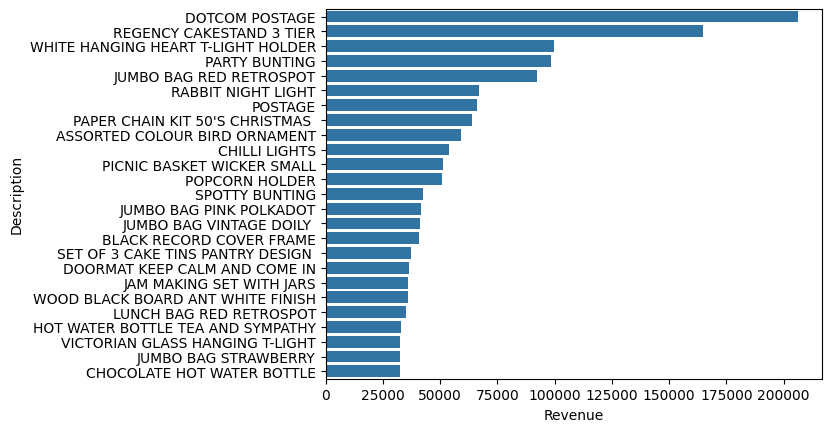

In [9]:
# Revenue Distribution of the top selling products
sns.barplot(data=product_sales.head(25), x='Revenue', y='Description')
plt.show()

In [10]:
# Find the percentage of total revenue contributed by top 20% of the product.
top_20_percent_product = round((product_sales.index[-1]+1)*0.2)
revenue_percent = product_sales.iloc[top_20_percent_product, 3]
print(f'The top 20% of the products contributes for {round(revenue_percent, 2)}% of the total revenue.')

The top 20% of the products contributes for 81.2% of the total revenue.


In [11]:
# Remove the unspecified countries from the database
df['Country'] = df['Country'].replace('Unspecified', np.nan)
df.dropna(subset=['Country'], inplace=True)

In [12]:
# Find the top 10 countries, most of the revenue is generated.
country_wise_revenue = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False)
country_wise_revenue = country_wise_revenue.reset_index()
country_wise_revenue.head(10)

,Country,TotalRevenue
0,United Kingdom,8187806.364
1,Netherlands,284661.540
2,EIRE,263276.820
3,Germany,221698.210
4,France,197403.900
5,Australia,137077.270
6,Switzerland,56385.350
7,Spain,54774.580
8,Belgium,40910.960
9,Sweden,36595.910


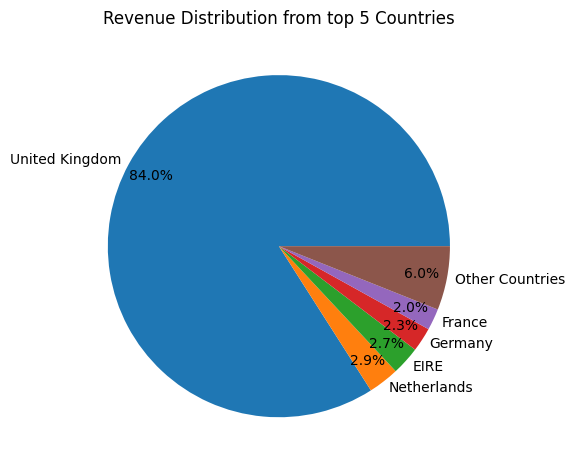

In [13]:
# Using a piechart, show the revenue distribution among the countries.
top5 = country_wise_revenue.head()
revenue_sum_after5 = country_wise_revenue.loc[5:]['TotalRevenue'].sum()
top5.loc[len(top5)] = ['Other Countries', revenue_sum_after5]
plt.pie(x=top5['TotalRevenue'], labels=top5['Country'], autopct='%1.1f%%', labeldistance=1.05, pctdistance=0.85)
plt.title('Revenue Distribution from top 5 Countries')
plt.tight_layout()
plt.show()

Revenue is highly concentrated in the United Kingdom (~84%), with all other countries contributing marginally. Heavy dependence on a single market introduces geographic risks. There is great opportunities of diversification.

In [14]:
# Convert the column into datetime format and create a separate column for month and year
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

In [15]:
# Create a new data frame to show the total monthly sales
monthly_revenue = df.groupby('MonthYear')['TotalRevenue'].sum()
monthly_revenue = monthly_revenue.reset_index()
monthly_revenue.sort_values(by='TotalRevenue', ascending=False)

,MonthYear,TotalRevenue
11,2024-11,1460790.500
10,2024-10,1070704.670
9,2024-09,1019400.772
0,2023-12,748957.020
5,2024-05,722277.640
6,2024-06,690937.340
3,2024-03,683267.080
8,2024-08,682149.480
7,2024-07,679874.701
1,2024-01,560000.260


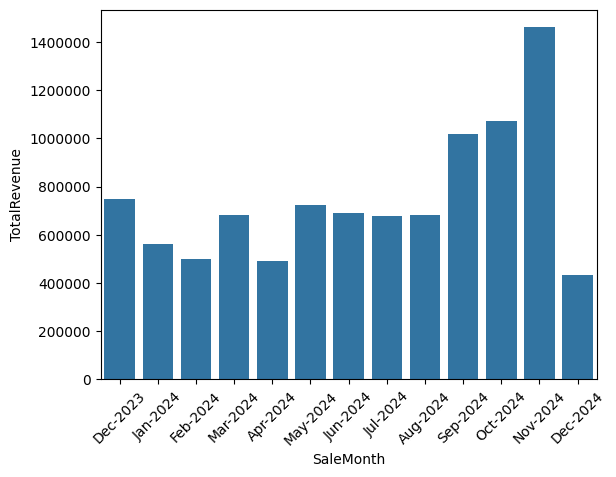

In [16]:
# Monthly Revenue distribution of the products
monthly_revenue['SaleMonth'] = monthly_revenue['MonthYear'].dt.strftime('%b-%Y')
monthly_revenue.sort_values(by='MonthYear', inplace=True)
sns.barplot(data=monthly_revenue, x='SaleMonth', y='TotalRevenue')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

The maximum revenue is generated in the November month of 2024 followed by October and September month of the same year.

<Axes: >

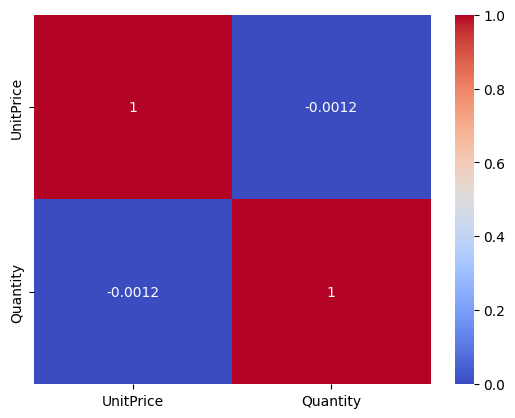

In [17]:
# Find the correlation between price and purchased quantity.
price_qty_corr = df[['UnitPrice', 'Quantity']].corr()
sns.heatmap(price_qty_corr, annot=True, cmap='coolwarm')

There is a very minimal negative correlation between price of the product and purchased quantity.

In [18]:
# Find the top 10 customers based on total revenue.
customer_revenue = df.groupby('CustomerID')['TotalRevenue'].sum().sort_values(ascending=False)
customer_revenue = customer_revenue.reset_index()
customer_revenue.head(10)

,CustomerID,TotalRevenue
0,14646.0,280806.03
1,18102.0,257427.99
2,17450.0,188789.54
3,14911.0,157800.58
4,12415.0,127280.00
5,14156.0,118286.81
6,17511.0,92176.49
7,14096.0,79056.79
8,17841.0,72694.56
9,15311.0,68889.09


In [19]:
# Create new columns to display the cummulative revenue and its percentage.
customer_revenue['CummulativeRevenue'] = customer_revenue['TotalRevenue'].cumsum()
total_revenue_generated = customer_revenue['CummulativeRevenue'].iloc[-1]
customer_revenue['CummulativeRevenuePercent'] = round((100*customer_revenue['CummulativeRevenue']/total_revenue_generated), 2)
customer_revenue

,CustomerID,TotalRevenue,CummulativeRevenue,CummulativeRevenuePercent
0,14646.0,280806.03,280806.030,2.88
1,18102.0,257427.99,538234.020,5.52
2,17450.0,188789.54,727023.560,7.46
3,14911.0,157800.58,884824.140,9.08
4,12415.0,127280.00,1012104.140,10.39
...,...,...,...,...
4367,14547.0,-7188.09,9782996.534,100.41
4368,17883.0,-8665.39,9774331.144,100.32
4369,14766.0,-8707.86,9765623.284,100.23
4370,17744.0,-10884.01,9754739.274,100.12


In [20]:
# Find the total revenue generated by the top 10% of customers.
total_customers = len(customer_revenue)
ten_percent_customers = round(0.1*total_customers)
revenue_generated = customer_revenue['CummulativeRevenuePercent'].iloc[ten_percent_customers]
print(f'The {revenue_generated}% of the total revenue is generated from the top 10% of the customers.')

The 58.16% of the total revenue is generated from the top 10% of the customers.


In [21]:
# Which are the top selling products ?
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head()

Description
POPCORN HOLDER                        56447
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53751
JUMBO BAG RED RETROSPOT               47363
WHITE HANGING HEART T-LIGHT HOLDER    39122
ASSORTED COLOUR BIRD ORNAMENT         36199
Name: Quantity, dtype: int64

In [22]:
# Find out the 10 most repeated customers (only purchases).
df['OrderType'] = df['Quantity'].apply(lambda x: 'Purchase' if x>=0 else 'Return')
repeat_customers = df[df['OrderType']=='Purchase'].groupby('CustomerID')['CustomerID'].count()
repeat_customers.sort_values(ascending=False).head(10)

CustomerID
17841.0    10426
14911.0     7605
14096.0     6775
12748.0     6065
14606.0     3564
15311.0     3199
14646.0     2710
13089.0     2435
13263.0     2203
14298.0     2195
Name: CustomerID, dtype: int64

In [23]:
# Find the top 5 items that are most returned.
returned_items = df[df['OrderType']=='Return'].groupby('Description')['Quantity'].sum()
returned_items.sort_values().head()

Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
TRAVEL CARD WALLET I LOVE LONDON      -19201
ROTATING SILVER ANGELS T-LIGHT HLDR    -9376
TRAVEL CARD WALLET VINTAGE ROSE        -9058
Name: Quantity, dtype: int64

#### RFM (Recency Frequency Monetary) Analysis

In [24]:
# Create a snapshot date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2024-12-10 12:50:00')

In [25]:
# Create a RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',                                  
    'TotalRevenue': 'sum'})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,327,2,0.00
1,12347.0,2,56,4697.94
2,12348.0,10,10,1850.05
3,12349.0,9,15,1936.85
4,12350.0,7,5,375.78
...,...,...,...,...
4367,18280.0,198,3,188.02
4368,18281.0,1,3,89.87
4369,18282.0,8,8,236.60
4370,18283.0,1,208,4664.83


In [35]:
# Filter the customers whose Recency, Frequency and Monetary is more than its median
avg_recency = rfm['Recency'].median()
avg_frequency = rfm['Frequency'].median()
avg_monetary = rfm['Monetary'].median()

high_value_customers = rfm[(rfm['Recency']<=avg_recency) & (rfm['Frequency']>=avg_frequency) & (rfm['Monetary']>=avg_monetary)]
high_value_customers

,CustomerID,Recency,Frequency,Monetary
1,12347.0,2,56,4697.94
5,12352.0,2,42,1818.55
7,12354.0,2,31,1331.18
9,12356.0,4,22,4573.68
10,12357.0,3,42,6995.12
...,...,...,...,...
4351,18257.0,2,56,2908.16
4353,18260.0,1,46,2891.51
4357,18265.0,2,20,917.63
4361,18272.0,1,62,3598.32


These customers purchase frequently and recently, suggesting strong retention and consistent engagement and above average spendings

In [27]:
# Find the customers whose spendings is more than median, but frequency is less than the median.
rfm[(rfm['Recency']<=avg_recency) & (rfm['Frequency']<=avg_frequency) & (rfm['Monetary']>=avg_monetary)]

,CustomerID,Recency,Frequency,Monetary
11,12358.0,2,7,1197.86
38,12394.0,1,12,1385.75
65,12427.0,1,17,854.83
73,12435.0,4,14,7991.25
129,12507.0,1,10,1348.66
...,...,...,...,...
4009,17788.0,3,5,1155.99
4052,17856.0,2,13,1445.85
4151,17980.0,2,15,879.78
4286,18173.0,2,12,2158.00


The above customers have spending potential and they have recently visited the site as well. But, their frequency is less. A customer retention focus strategies needs to be implemented.

In [31]:
# Find the customers whose spendings and frequency is more than median and recency is more than 10 days.
rfm[(rfm['Recency']>10) & (rfm['Frequency']>=avg_frequency) & (rfm['Monetary']>=avg_monetary)]

,CustomerID,Recency,Frequency,Monetary
28,12379.0,14,24,1156.73
48,12407.0,17,34,1964.93
59,12421.0,16,23,937.33
60,12422.0,30,17,886.87
90,12455.0,11,28,2638.01
...,...,...,...,...
4201,18061.0,11,26,2233.72
4226,18093.0,17,20,2214.14
4227,18094.0,17,27,3338.39
4307,18202.0,24,23,1793.78


The above customers who frequently visits the site also have good spending potential, but they haven't visited the site from quite a long time. Any special offer can be sent to those customers to bring them back.

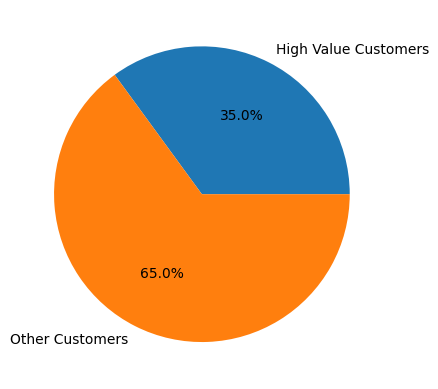

In [40]:
# Find the percentage of high value customers in the entire data.
sizes = [len(high_value_customers), len(rfm)-len(high_value_customers)]
labels = ['High Value Customers', 'Other Customers']
plt.pie(x=sizes, labels=labels, autopct='%1.1f%%')
plt.show()

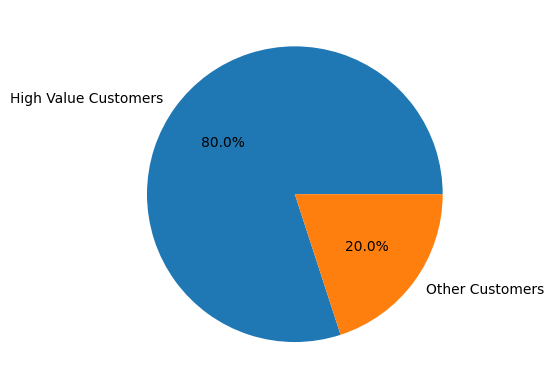

In [51]:
# Find the revenue share by the high value customers and other customers.
total_revenue = rfm['Monetary'].sum()
high_value_customers_revenue = high_value_customers['Monetary'].sum()
revenues = [high_value_customers_revenue, total_revenue-high_value_customers_revenue]
labels = ['High Value Customers', 'Other Customers']
plt.pie(x=revenues, labels=labels, autopct='%1.1f%%')
plt.show()

Although high-value customers represent only 35% of the total customer base, they contribute a significantly higher proportion of revenue (ie 80%), highlighting the importance of retention and targeted marketing strategies.

### 📊 Final Business Insights & Recommendations

🎯 Revenue Concentration (Geographic Risk)
The United Kingdom contributes ~84% of total revenue.
Remaining countries contribute marginally.
The business is heavily dependent on a single market, creating geographic risk.

🛒 Product Concentration (Pareto Analysis)
A small percentage of products generates ~80% of total revenue.
Revenue is driven by a limited set of high-performing products.

👥 Customer Segmentation (RFM Analysis)
Identified high-value customers with Low Recency (recent buyers), High Frequency (repeat purchases) and High Monetary value (high spend).
A small segment of customers contributes a disproportionately high share of revenue.

🔁 Customer Behavior Patterns
High-value customers purchase more frequently and recently and spend significantly higher amounts.
Strong engagement and retention behavior exists among top customers.

⚠️ Business Risk
Heavy reliance on UK market and small customer segment.
Losing key customers or market demand may significantly impact revenue.

### 📈 Growth Opportunities & Recommendations

Convert mid-tier customers → high-value segment
Expand geographically (EU, Australia)
Promote high-performing products
Diversify revenue streams to reduce dependency
Prioritize inventory for top products
Bundle slow-moving products with bestsellers
Launch loyalty programs and provide exclusive offers.
Focus on retention over acquisition